##Downloads

In [18]:
!pip install -q datasets transformers accelerate

In [19]:
from datasets import load_dataset
import pandas as pd
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from collections import Counter

In [20]:
# Load dataset
dataset = load_dataset("Elriggs/openwebtext-100k")

# Convert the training split to a DataFrame for convenient viewing
df = pd.DataFrame(dataset['train'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/366 [00:00<?, ?B/s]

data/train-00000-of-00001-10a4de027237ea(…):   0%|          | 0.00/303M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

In [21]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B")

# Print a tokenization example
print(tokenizer("Hello world"))

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'input_ids': [9707, 1879], 'attention_mask': [1, 1]}


## Inspection

In [22]:
# Display the first few rows and column information
print(f"Dataset size: {df.shape}")
display(df.head())

Dataset size: (100000, 1)


,text
0,"Port-au-Prince, Haiti (CNN) -- Earthquake vict..."
1,Former secretary of state Hillary Clinton meet...
2,The opinions expressed by columnists are their...
3,BIGBANG is one of those musical entities that ...
4,WHAT?!??! I know. That’s what you’re saying ri...


In [23]:
# Find NaN values
nan_in_text = df['text'].isnull().sum()
print(f"Number of NaN values in the 'text' column: {nan_in_text}")

# Find empty strings (after stripping whitespace)
empty_strings_count = (df['text'].astype(str).str.strip() == '').sum()
print(f"Number of empty strings in the 'text' column: {empty_strings_count}")

Number of NaN values in the 'text' column: 0
Number of empty strings in the 'text' column: 0


In [24]:
# Count complete duplicates in the 'text' column
duplicate_rows_count = df['text'].duplicated().sum()

print(f"Number of complete duplicates in the dataset: {duplicate_rows_count}")

Number of complete duplicates in the dataset: 0


```markdown
### Text length analysis (characters)
```

In [25]:
# Calculate lengths of all strings in the 'text' column
lengths = df['text'].str.len()

# Calculate statistics
mean_len = lengths.mean()
median_len = lengths.median()
mode_len = lengths.mode()[0]
min_len = lengths.min()
max_len = lengths.max()

# Output results
print(f"Average string length: {mean_len:.2f}")
print(f"Median length: {median_len}")
print(f"Mode length: {mode_len}")
print(f"Shortest string length: {min_len}")
print(f"Longest string length: {max_len}")

Average string length: 4924.73
Median length: 3179.0
Mode length: 100000
Shortest string length: 465
Longest string length: 100000


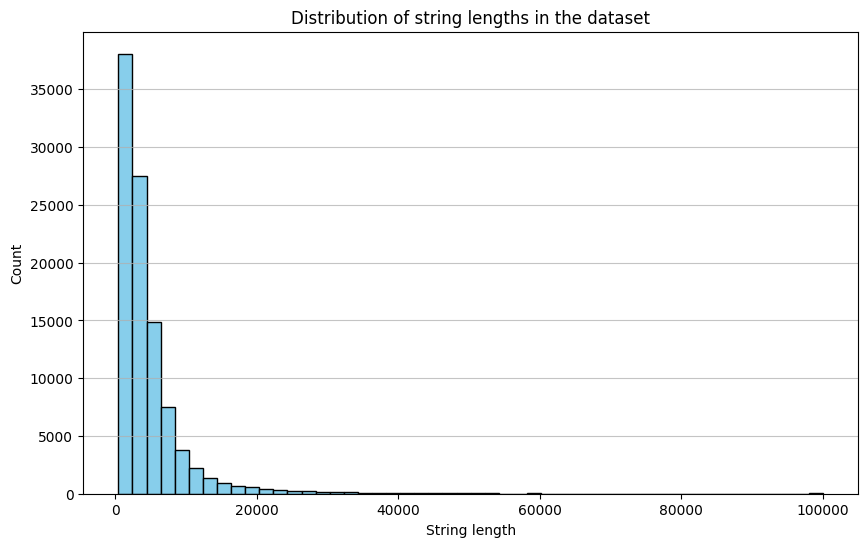

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of string lengths in the dataset')
plt.xlabel('String length')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

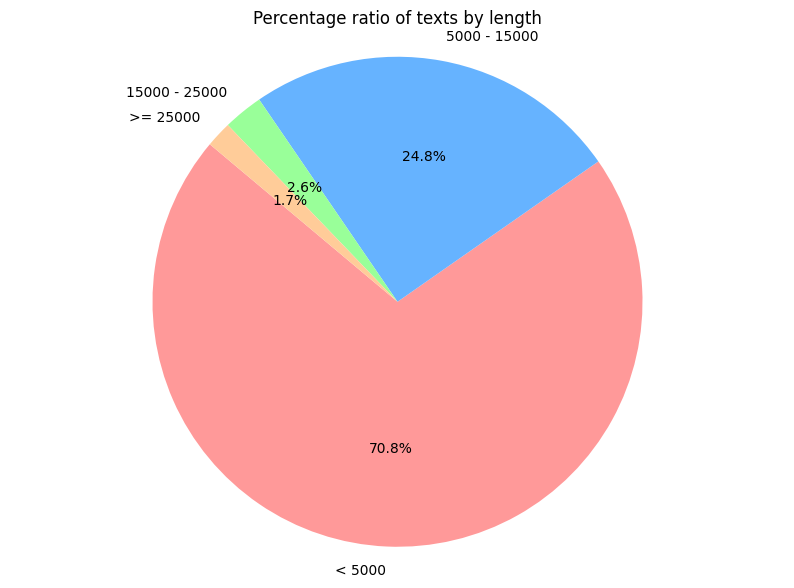

In [27]:
# Define bin edges
bins = [0, 5000, 15000, 25000, float('inf')]
labels = ['< 5000', '5000 - 15000', '15000 - 25000', '>= 25000']

# Categorize data
length_categories = pd.cut(lengths, bins=bins, labels=labels, right=False)
counts = length_categories.value_counts().reindex(labels)

# Plot pie chart
plt.figure(figsize=(10, 7))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Percentage ratio of texts by length')
plt.axis('equal')
plt.show()

In [28]:
# Calculate percentiles
p95 = lengths.quantile(0.95)
p97 = lengths.quantile(0.97)

print(f"95th percentile: {p95:.2f} ")
print(f"\n97th percentile: {p97:.2f}")

95th percentile: 13875.05 

97th percentile: 18528.06


In [29]:
def token_lengths_batched(texts, tokenizer, batch_size=256):
    lengths = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i + batch_size].tolist()

        encoded = tokenizer(
            batch,
            truncation=False,
            padding=False,
            add_special_tokens=True,
        )

        lengths.extend(len(ids) for ids in encoded["input_ids"])

    return lengths

token_lengths = token_lengths_batched(df["text"], tokenizer, batch_size=256)
df["token_length"] = token_lengths

  0%|          | 0/391 [00:00<?, ?it/s]

```markdown
### Text length analysis (tokens)
```

In [30]:
# Calculate statistics for token lengths
token_lengths_series = df['token_length']

mean_token_len = token_lengths_series.mean()
median_token_len = token_lengths_series.median()
mode_token_len = token_lengths_series.mode()[0]
min_token_len = token_lengths_series.min()
max_token_len = token_lengths_series.max()

# Output results
print(f"Average text length in tokens: {mean_token_len:.2f}")
print(f"Median text length in tokens: {median_token_len}")
print(f"Mode text length in tokens: {mode_token_len}")
print(f"Shortest text length in tokens: {min_token_len}")
print(f"Longest text length in tokens: {max_token_len}")

Average text length in tokens: 1089.44
Median text length in tokens: 687.0
Mode text length in tokens: 357
Shortest text length in tokens: 137
Longest text length in tokens: 47276


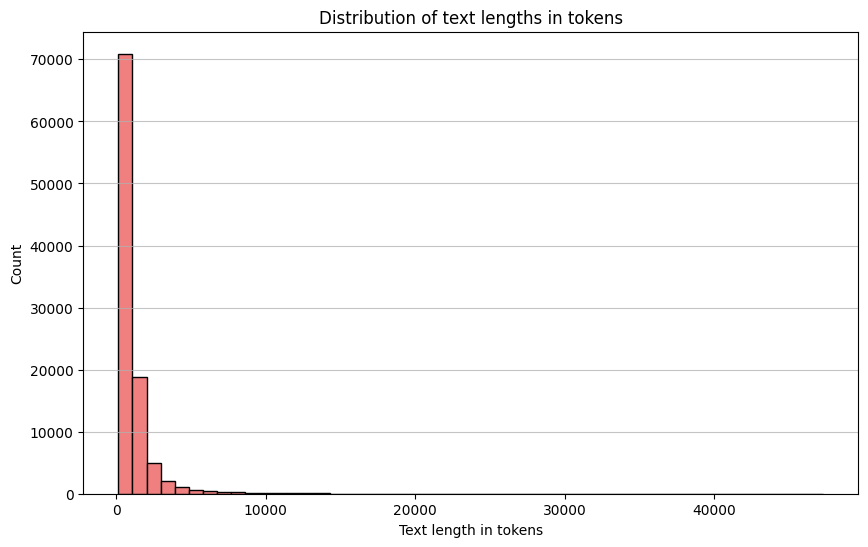

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['token_length'], bins=50, color='lightcoral', edgecolor='black')
plt.title('Distribution of text lengths in tokens')
plt.xlabel('Text length in tokens')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

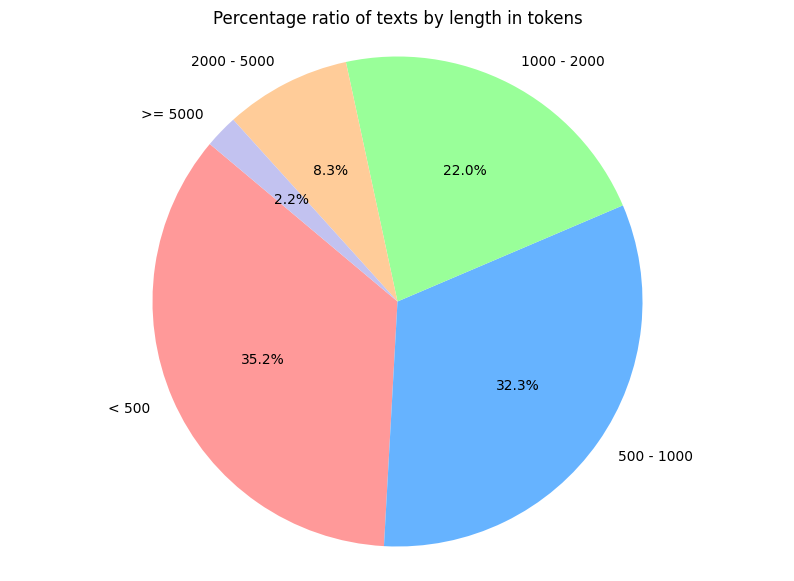

In [32]:
# Define bin edges for tokens
token_bins = [0, 500, 1000, 2000, 5000, float('inf')]
token_labels = ['< 500', '500 - 1000', '1000 - 2000', '2000 - 5000', '>= 5000']

# Categorize data by token length
token_length_categories = pd.cut(df['token_length'], bins=token_bins, labels=token_labels, right=False)
token_counts = token_length_categories.value_counts().reindex(token_labels)

# Plot pie chart for token lengths
plt.figure(figsize=(10, 7))
plt.pie(token_counts, labels=token_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'])
plt.title('Percentage ratio of texts by length in tokens')
plt.axis('equal')
plt.show()

In [33]:
# Calculate percentiles for token lengths
p95_tokens = token_lengths_series.quantile(0.95)
p97_tokens = token_lengths_series.quantile(0.97)

print(f"95th percentile (tokens): {p95_tokens:.2f} ")
print(f"\n97th percentile (tokens): {p97_tokens:.2f}")

95th percentile (tokens): 3099.00 

97th percentile (tokens): 4167.00


## Analysis of the meaningfulness of text content

### Non-Latin character ratio analysis

In [34]:
def calculate_non_latin_percentage(text):
    if not isinstance(text, str):
        return 0.0 # Handle non-string inputs, e.g., NaNs

    latin_count = 0
    non_latin_count = 0

    for char in text:
        # Check if the character is a Latin letter (a-z, A-Z)
        if 'a' <= char <= 'z' or 'A' <= char <= 'Z':
            latin_count += 1
        elif char.isalpha(): # Check if it's any other alphabetic character (e.g., Cyrillic, Greek, Arabic)
            non_latin_count += 1
        # Non-alphabetic characters (numbers, punctuation, spaces) are ignored for this specific count

    total_alphabetic_chars = latin_count + non_latin_count
    if total_alphabetic_chars == 0:
        return 0.0
    return (non_latin_count / total_alphabetic_chars) * 100

# Apply the function to the 'text' column
df['non_latin_percentage'] = df['text'].apply(calculate_non_latin_percentage)

In [35]:
# Count the number of texts where the non-Latin percentage is greater than specified
percent = 5
texts_with_high_non_latin = df[df['non_latin_percentage'] > percent].shape[0]

print(f"Number of texts where more than {percent}% of the content is non-Latin: {texts_with_high_non_latin}")

Number of texts where more than 5% of the content is non-Latin: 112


In [36]:
# Display all texts where the non-Latin percentage is greater than 50%
display(df[df['non_latin_percentage'] > 50][['text', 'non_latin_percentage']])

,text,non_latin_percentage
13821,I\n\nРелигиозную веру можно сравнить с покровн...,99.560604
15362,1.\n\nKORNのUSツアーにサポートとして参加しているBABYMETAL。\n\n初日...,87.528604
17405,Звездный крик\n\nЗагадочные космические вспышк...,99.301412
18016,座標:\n\nディアトロフ峠事件（ディアトロフとうげじけん）とは、1959年2月2日の夜、当...,94.978423
20708,[한겨레]\n\n가수 고 김광석씨 부인 서해순씨가 지난 17일 용인시 기흥구 자신의...,99.752619
25163,Learning to learn\n\nПочему алгоритмы оптимиза...,78.799868
34115,This journal has been placed in memorial statu...,96.892562
43124,Hi! Hi!\n\nToday we are happy to share with yo...,56.016043
44175,Δραματικά είναι τα στοιχεία για την κατάσταση ...,100.000000
46471,This video is no longer available\n\nThis vide...,68.386023


In [37]:
display(df[df['non_latin_percentage'] >= 5][['text', 'non_latin_percentage']].head(5))

,text,non_latin_percentage
139,Caution: JavaScript execution is disabled in y...,12.181617
1748,/\n\nOtomatik kollu bariyer sistemleri endüstr...,8.598266
2142,Русский English | Deutsch Blog Concepts Studio...,38.006839
2869,"En bloggläsare skriver till mig, men tycker at...",5.580054
3496,jjw Profile Joined July 2011 Korea (South) 6 P...,12.438443


### Unique character count analysis

In [38]:
def count_unique_chars(text):
    if not isinstance(text, str):
        return 0
    return len(set(text))

df['unique_char_count'] = df['text'].apply(count_unique_chars)

In [39]:
sym_count = 26
texts_with_few_unique_chars = df[df['unique_char_count'] < sym_count].shape[0]

print(f"Number of texts with fewer than {sym_count} unique characters: {texts_with_few_unique_chars}")

Number of texts with fewer than 26 unique characters: 2


In [40]:
display(df[df['unique_char_count'] <= 26][['text', 'unique_char_count']].head(5))

,text,unique_char_count
18600,How do you feel when you're on the drug\n\nHow...,24
66330,I donty understand what this is I think it is ...,25


### N-gram repetition ratio analysis

In [41]:
def repeated_ngram_ratio(text, n=3):
    words = text.split()
    if len(words) < n:
        return 0

    ngrams = [tuple(words[i:i+n]) for i in range(len(words)-n+1)]
    unique = len(set(ngrams))
    total = len(ngrams)

    return 1 - unique / total

In [42]:
df["ngram_repetition"] = df["text"].apply(repeated_ngram_ratio)

suspicious = df[df["ngram_repetition"] > 0.5]
display(suspicious.head(5))

,text,token_length,non_latin_percentage,unique_char_count,ngram_repetition
686,• Scaffolds • Cord Blood & Regenerative Medici...,13199,0.0,81,0.581240
1192,Note: Latency in the video stream means index ...,8047,0.0,69,0.505869
1588,"View Photos Charlie Magee, George Lepp, Mark B...",1154,0.0,52,0.817906
2129,"Untitled a guest Oct 21st, 2012 216 Never a gu...",872,0.0,64,0.509804
2948,EternaLEnVy Profile Joined February 2009 Canad...,7846,0.0,78,0.597068


### Maximum word frequency analysis

In [43]:
def max_token_ratio(text):
    words = text.split()
    if not words:
        return 0
    counts = Counter(words)
    return max(counts.values()) / len(words)

In [44]:
df["max_word_ratio"] = df["text"].apply(max_token_ratio)

suspicious = df[df["max_word_ratio"] > 0.5]
print(len(suspicious))

3


In [45]:
display(suspicious)

,text,token_length,non_latin_percentage,unique_char_count,ngram_repetition,max_word_ratio
74793,This meetup is posted across multiple groups s...,3567,0.02642,84,0.616524,0.686916
78781,Soulburn Color Scheme\n\nEasy on eyes sublime ...,332,0.00000,45,0.716867,0.714286
81380,Here's your Home Run Derby open thread. I will...,277,0.00000,47,0.230769,0.590909


## Conclusions

1. **Data Integrity**: There are no `NaN` values, entirely empty strings, or extremely short texts in the dataset.
2. **Text Length**: The character count varies significantly with some very long documents. When measured in tokens, the distribution is more normalized, though a long tail of high-length texts still exists.
3. **Language**: Non-English texts or texts with a high ratio of non-Latin characters are present but constitute a very small fraction of the dataset.
4. **Meaningfulness**: A negligible number of texts exhibit suspicious patterns such as high n-gram repetition or excessive word frequency, suggesting the overall content quality is high.